# Build a Hierarchical clustering mode

## Data preprocessing

### Importing the libraries 📚

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Importing the dataset 📑

In [3]:
dataset = pd.read_csv("Mall_Customers.csv")
x = dataset.iloc[:, [3, 4]].values

FileNotFoundError: [Errno 2] No such file or directory: 'Mall_Customers.csv'

In [51]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [52]:
import plotly.express as px

fig = px.box(dataset, x="Genre", y="Annual Income (k$)", color="Genre")
fig.show()

## Using the dendrogram to find the optimal number of clusters

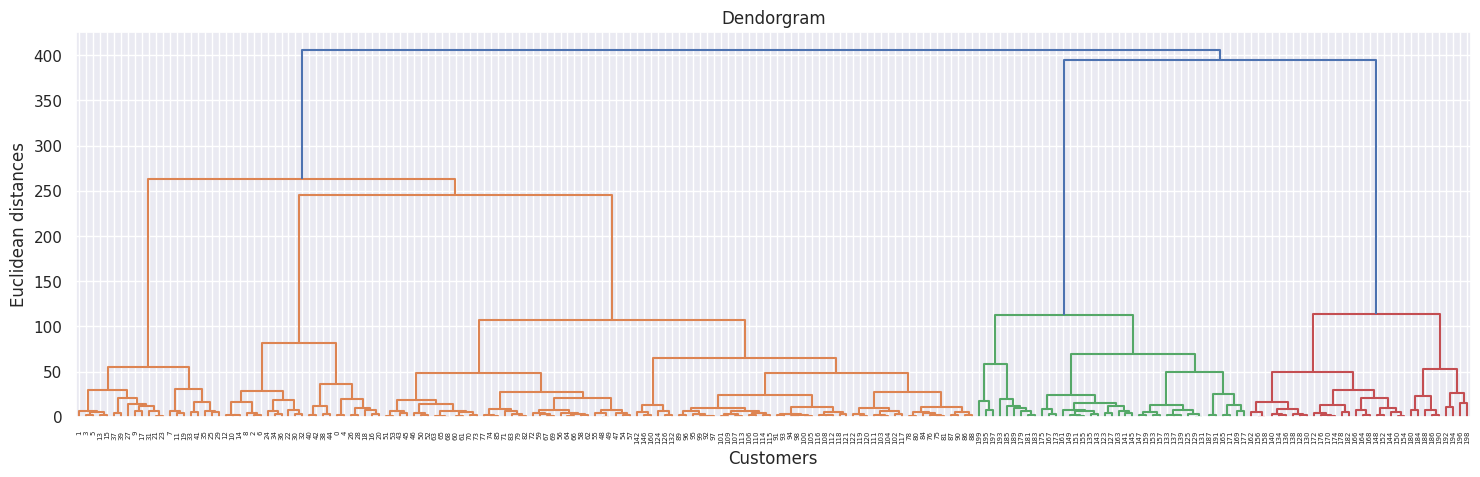

In [53]:
import scipy.cluster.hierarchy as sch
plt.subplots(figsize=(18, 5))
dendrogram = sch.dendrogram(sch.linkage(x, method='ward'))
plt.title("Dendorgram")
plt.xlabel("Customers")
plt.ylabel("Euclidean distances")
plt.show()

## Training the Hierarchical Clustering model on the dataset

In [54]:
from sklearn.cluster import AgglomerativeClustering
hc_model = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage="ward")
y_hc = hc_model.fit_predict(x)

In [55]:
y_hc

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

## Visualizing the Clusters

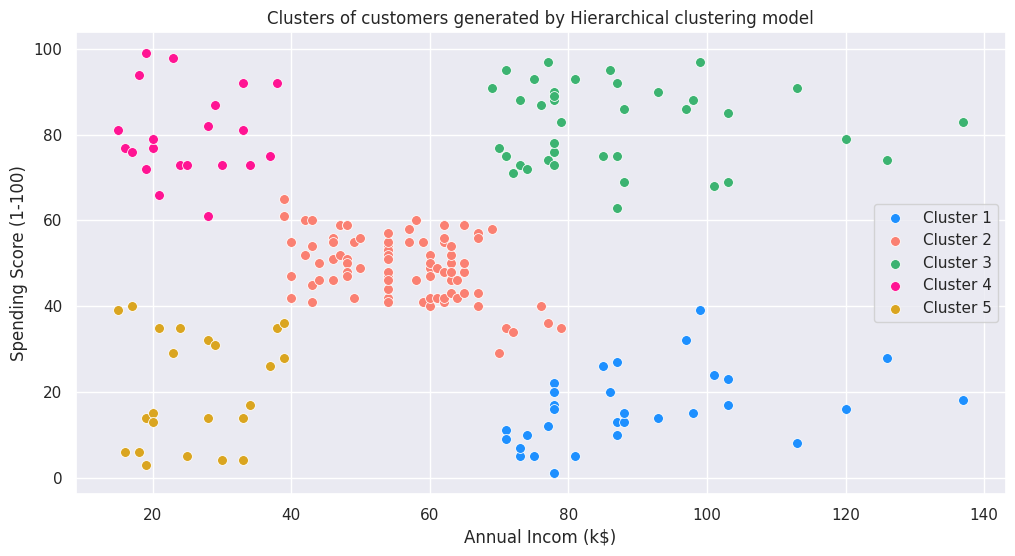

In [56]:
import seaborn as sns

plt.subplots(figsize=(12, 6))
sns.set_theme()
sns.scatterplot(x=x[y_hc==0, 0], y=x[y_hc==0, 1], s=50, c='dodgerblue', label='Cluster 1')
sns.scatterplot(x=x[y_hc==1, 0], y=x[y_hc==1, 1], s=50, c='salmon', label='Cluster 2')
sns.scatterplot(x=x[y_hc==2, 0], y=x[y_hc==2, 1], s=50, c='mediumseagreen', label='Cluster 3')
sns.scatterplot(x=x[y_hc==3, 0], y=x[y_hc==3, 1], s=50, c='deeppink', label='Cluster 4')
sns.scatterplot(x=x[y_hc==4, 0], y=x[y_hc==4, 1], s=50, c='goldenrod', label='Cluster 5')
plt.title('Clusters of customers generated by Hierarchical clustering model')
plt.xlabel('Annual Incom (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()